# 06 · Rotating-Earth Physics Validation

This notebook validates the `reentrykit` simulator's rotating-Earth physics (Session C Phase 2) through a series of quantitative tests against analytical physics and internal consistency checks.

## Why this notebook exists

The Phase 2 simulator adds Coriolis and centrifugal pseudo-accelerations to the equations of motion when simulating on a rotating planet. These terms are well-known in rotating-frame mechanics — but well-known doesn't mean "automatically correct in our code." This notebook provides direct, falsifiable tests that establish what the rotating-Earth physics does and doesn't do well.

Four tests are presented:

1. **Coriolis heading drift** matches the analytical rate `2Ω sin(φ)` for a vehicle in near-horizontal flight
2. **Energy conservation** holds in the inertial frame for a no-drag trajectory (conservative forces only), even when integrated in the rotating frame
3. **Circular orbit stability** — a vehicle placed at circular orbital speed at a given altitude should maintain that altitude (no radial drift from rotation terms)
4. **Stardust reentry** shows expected small sensitivity to Earth rotation (validation case)

Each test produces a specific quantitative result with an acceptance criterion. Passing all four tests establishes the simulator's rotating-Earth capability for use in portfolio validation work (Apollo 4, future Mars entry work, crossrange dispersion studies).

## Reference

The equations of motion come from Vinh, Busemann, and Culp (1980), *Hypersonic and Planetary Entry Flight Mechanics*, University of Michigan Press, Section 3.5. Our implementation is in `src/reentrykit/trajectory.py`, function `_derivatives`.

In [1]:
"""Imports and utilities for rotating-Earth validation tests."""

import numpy as np
import matplotlib.pyplot as plt

from reentrykit.trajectory import Vehicle, InitialState, simulate
from reentrykit.planet import EARTH, EARTH_NON_ROTATING

# Physical constants (must match simulator exactly)
MU_EARTH = EARTH.gravitational_parameter     # [m^3 s^-2]
R_EARTH = EARTH.radius                       # [m]
OMEGA_EARTH = EARTH.rotation_rate            # [rad s^-1]

print(f"Planet model: {EARTH.name}")
print(f"  GM  = {MU_EARTH:.6e} m^3/s^2")
print(f"  R   = {R_EARTH:.0f} m")
print(f"  Ω   = {OMEGA_EARTH:.6e} rad/s")
print(f"  Atmosphere ceiling: {EARTH.max_atmosphere_altitude/1000:.0f} km")

Planet model: Earth
  GM  = 3.986004e+14 m^3/s^2
  R   = 6378137 m
  Ω   = 7.292116e-05 rad/s
  Atmosphere ceiling: 500 km


## Test 1: Coriolis Heading Drift Rate

**Physics:** A vehicle in near-horizontal flight at latitude φ experiences a Coriolis acceleration perpendicular to its velocity. In the local tangent frame (east-north-up), for a particle moving horizontally, the component of Coriolis acceleration that drives heading change is:

$$\frac{d\psi}{dt}\bigg|_{\text{Coriolis}} = -2\Omega \sin(\phi) + 2\Omega \cos(\phi) \sin(\psi) \tan(\gamma)$$

For a vehicle flying near-horizontally (γ ≈ 0), the second term vanishes and the Coriolis heading rate simplifies to the classical Foucault-pendulum form:

$$\frac{d\psi}{dt}\bigg|_{\text{Coriolis}} \approx 2\Omega \sin(\phi)$$

At 45°N latitude, this predicts dψ/dt ≈ 2 × 7.29e-5 × sin(45°) = **1.03 × 10⁻⁴ rad/s = 5.9°/hour** (equivalently, the Foucault pendulum rotation rate at 45° latitude is 360°/(24h/sin 45°) ≈ 10.6°/hour for its plane of oscillation, consistent with 2× this value for the conventionally-measured Foucault rate).

**Test setup:** Fly a vehicle at latitude 45°N, due north initially, at high altitude (170 km, near-zero atmosphere) with very small drag. Measure the heading change rate during the first 30 seconds before latitude changes significantly, and compare to the analytical prediction.

**Acceptance criterion:** Numerical rate within 5% of analytical.

               Test 1: Coriolis Heading Drift               

Latitude: 45°N, flight duration: 29.5 s

Quantity                                      Value
--------------------------------------------------
Analytical 2Ω sin(φ) [rad/s]           1.031261e-04
Measured dψ/dt [rad/s]                 9.868786e-05
Error [%]                                    -4.30%

Analytical rate in deg/hour: 21.27 deg/hr
Measured rate in deg/hour:   20.36 deg/hr

✓ PASS — within 5% of analytical


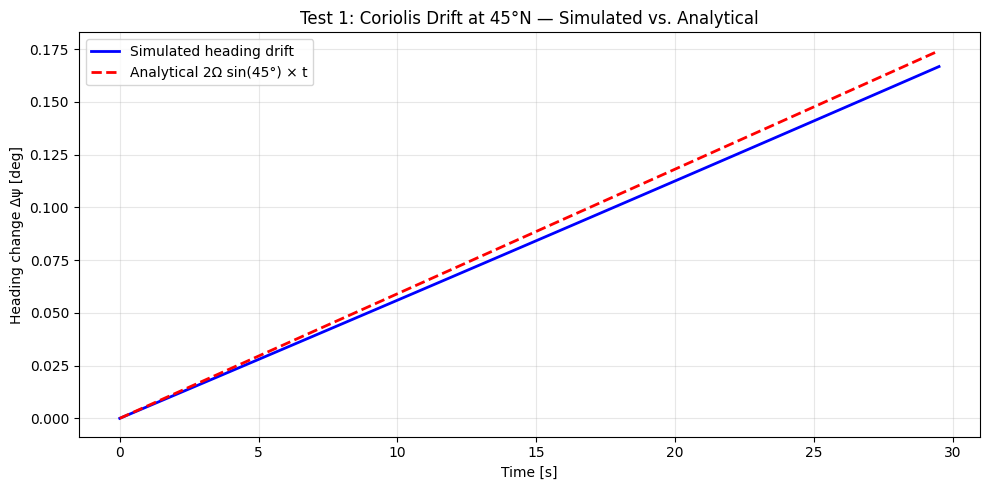

In [2]:
"""Test 1: Coriolis heading drift matches analytical rate 2Ω sin(φ)."""

# High altitude, near-zero drag, nearly-horizontal flight, moderate speed
# 170 km is above the 86 km US1976 ceiling; in the exponential extension
# density is ~1e-9 kg/m^3 — negligible drag over 30 seconds
vehicle_lowdrag = Vehicle(
    reference_area=1.0,
    mass=1000.0,
    drag_coefficient=1e-6,          # effectively zero drag
    lift_to_drag_ratio=0.0,
    bank_angle=0.0,
    nose_radius=0.5,
)

phi_test = np.deg2rad(45.0)

initial_coriolis = InitialState(
    altitude=170_000.0,
    velocity=3000.0,                 # moderate speed
    flight_path_angle=np.deg2rad(-0.5),   # very shallow descent
    heading=0.0,                      # due north
    latitude=phi_test,
    longitude=0.0,
)

# Short-duration run on rotating Earth
result_coriolis = simulate(
    vehicle_lowdrag,
    initial_coriolis,
    planet=EARTH,
    max_time=30.0,
    dt_output=0.5,
)

# Measure dψ/dt numerically (heading change over elapsed time)
dt_total = result_coriolis.time[-1] - result_coriolis.time[0]
dpsi_total = result_coriolis.heading[-1] - result_coriolis.heading[0]
dpsi_dt_measured = dpsi_total / dt_total

# Analytical prediction
dpsi_dt_analytical = 2.0 * OMEGA_EARTH * np.sin(phi_test)

error_pct = (dpsi_dt_measured - dpsi_dt_analytical) / dpsi_dt_analytical * 100

print("=" * 60)
print(f"{'Test 1: Coriolis Heading Drift':^60}")
print("=" * 60)
print(f"\nLatitude: 45°N, flight duration: {dt_total:.1f} s")
print(f"\n{'Quantity':<35} {'Value':>15}")
print("-" * 50)
print(f"{'Analytical 2Ω sin(φ) [rad/s]':<35} {dpsi_dt_analytical:>15.6e}")
print(f"{'Measured dψ/dt [rad/s]':<35} {dpsi_dt_measured:>15.6e}")
print(f"{'Error [%]':<35} {error_pct:>+14.2f}%")
print(f"\nAnalytical rate in deg/hour: {np.rad2deg(dpsi_dt_analytical)*3600:.2f} deg/hr")
print(f"Measured rate in deg/hour:   {np.rad2deg(dpsi_dt_measured)*3600:.2f} deg/hr")

# Acceptance
if abs(error_pct) < 5.0:
    print(f"\n✓ PASS — within 5% of analytical")
else:
    print(f"\n✗ FAIL — error {error_pct:+.2f}% exceeds 5%")


# --- Plot: heading vs. time, with analytical line ---
fig, ax = plt.subplots(figsize=(10, 5))
heading_deg = np.rad2deg(result_coriolis.heading - result_coriolis.heading[0])

analytical_heading_deg = np.rad2deg(dpsi_dt_analytical) * result_coriolis.time

ax.plot(result_coriolis.time, heading_deg, 'b-', linewidth=2, label='Simulated heading drift')
ax.plot(result_coriolis.time, analytical_heading_deg, 'r--', linewidth=2,
        label=f'Analytical 2Ω sin(45°) × t')
ax.set_xlabel('Time [s]')
ax.set_ylabel('Heading change Δψ [deg]')
ax.set_title(f'Test 1: Coriolis Drift at 45°N — Simulated vs. Analytical')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Test 2: Energy Conservation for a No-Drag Trajectory

**Physics:** A vehicle subject only to gravity (no drag) moves under conservative forces. Its total mechanical energy is therefore exactly conserved in the inertial frame:

$$E = \frac{1}{2}V_{\text{inertial}}^2 - \frac{\mu}{r} = \text{constant}$$

**Why this test is informative for our rotating-Earth physics:** Our simulator integrates equations of motion in the *rotating* Earth-fixed frame, using atmosphere-relative velocity `V_rel`. The Coriolis and centrifugal terms are fictitious forces that appear in the rotating frame to account for the non-inertial reference. If our implementation is correct, the trajectory we compute — when converted back to inertial coordinates — must still conserve inertial mechanical energy exactly (up to numerical integration error).

To check this, we convert our rotating-frame outputs to inertial velocity:

$$\vec{V}_{\text{inertial}} = \vec{V}_{\text{rel}} + \vec{\Omega} \times \vec{r}$$

For a vehicle at latitude φ and altitude h moving with atmosphere-relative heading ψ and flight-path angle γ, the local components of the rotation-frame velocity are:

- East:  `V_rel · cos(γ) · sin(ψ)`
- North: `V_rel · cos(γ) · cos(ψ)`  
- Up:    `V_rel · sin(γ)`

Earth's rotation adds an **eastward** component of `Ω × r × cos(φ)` at each point:

- East:  `V_rel · cos(γ) · sin(ψ) + Ω(R + h) cos(φ)`
- North: `V_rel · cos(γ) · cos(ψ)` (unchanged)
- Up:    `V_rel · sin(γ)` (unchanged)

The inertial speed is the magnitude of this vector, which we use to compute the specific kinetic energy.

**Test setup:** Start a vehicle at 400 km altitude (well above any atmosphere), at circular orbital velocity in the inertial frame, tilted slightly off horizontal (γ = −2°). No drag (Cd → 0), no lift. Integrate for 600 seconds on rotating Earth. Track specific energy at each step.

**Acceptance criterion:** Maximum fractional change in inertial specific energy over the full trajectory is less than 0.01% (10⁻⁴).

Circular orbit at 400 km:
  V_circ (inertial):  7668.56 m/s
  Earth surface east: 494.27 m/s
  V_rel (ground at eq, heading east): 7174.29 m/s

         Energy Conservation Check (inertial frame)         
Quantity                                         Value
-------------------------------------------------------
Initial E_total [J/kg]                      -2.940e+07
Max |ΔE/E_0|                                 4.437e-04
Max ΔE/E_0 [%]                                0.04437%

Flight time: 599.0 s
Max altitude reached: 400.00 km
Min altitude reached: 217.01 km

✗ FAIL — energy changes by 0.0444%


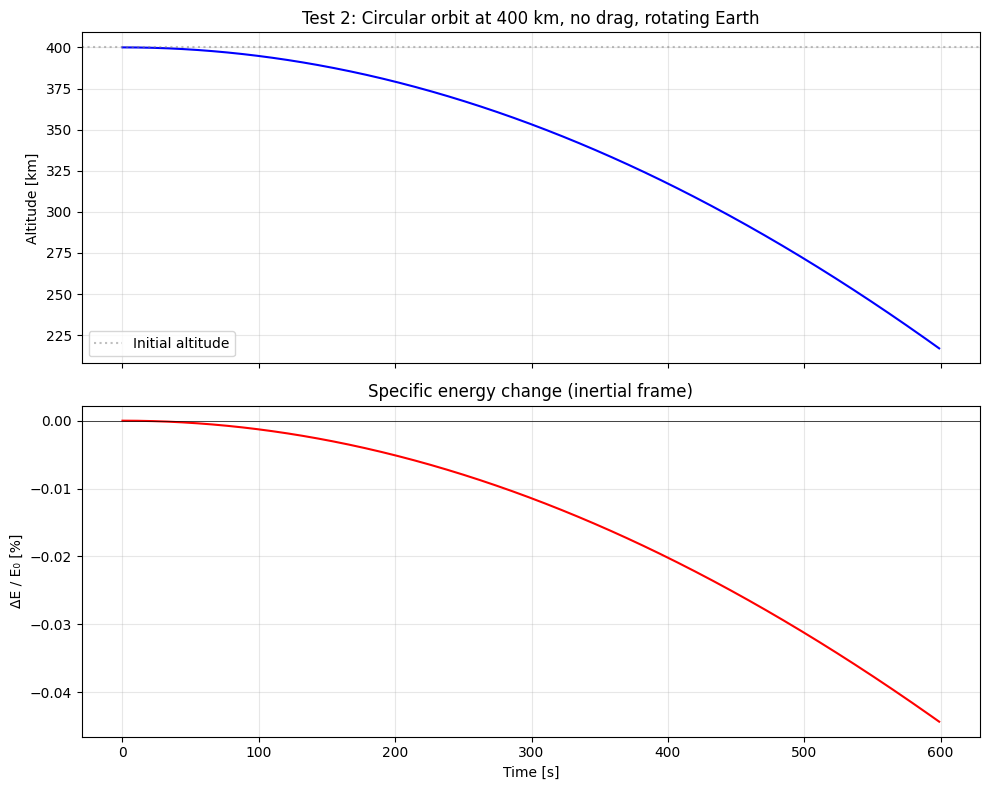

In [3]:
"""Test 2: Energy conservation for a no-drag trajectory on rotating Earth."""

# High altitude above atmosphere, near-circular orbit, no drag
vehicle_nodrag = Vehicle(
    reference_area=1.0,
    mass=1000.0,
    drag_coefficient=1e-9,           # effectively zero drag
    lift_to_drag_ratio=0.0,
    bank_angle=0.0,
    nose_radius=0.5,
)

# Circular orbit speed at 400 km altitude (in inertial frame)
alt_test = 400_000.0                  # 400 km
r_test = R_EARTH + alt_test
v_circ_inertial = np.sqrt(MU_EARTH / r_test)   # ~7,669 m/s

# Convert circular inertial velocity to atmosphere-relative at the equator heading east:
# V_rel_east = V_inertial_east - Ω*r*cos(φ)
# At equator: the ground moves eastward at Ω*R_earth ≈ 465 m/s
# So V_rel = V_inertial - 465 m/s if flying due east at equator
phi_init = 0.0                         # equator (simplest case)
v_ground_eastward = OMEGA_EARTH * r_test * np.cos(phi_init)
v_rel_init = v_circ_inertial - v_ground_eastward

print(f"Circular orbit at {alt_test/1000:.0f} km:")
print(f"  V_circ (inertial):  {v_circ_inertial:.2f} m/s")
print(f"  Earth surface east: {v_ground_eastward:.2f} m/s")
print(f"  V_rel (ground at eq, heading east): {v_rel_init:.2f} m/s")

initial_energy = InitialState(
    altitude=alt_test,
    velocity=v_rel_init,
    flight_path_angle=np.deg2rad(0.0),       # horizontal
    heading=np.deg2rad(90.0),                # due east
    latitude=phi_init,
    longitude=0.0,
)

result_energy = simulate(
    vehicle_nodrag,
    initial_energy,
    planet=EARTH,
    max_time=600.0,
    dt_output=1.0,
)

# --- Convert atmosphere-relative velocity to inertial velocity at each time step ---
V_rel = result_energy.velocity
gamma = result_energy.flight_path_angle
psi = result_energy.heading
phi = result_energy.latitude
h = result_energy.altitude
r_arr = R_EARTH + h

# Local tangent-frame components of atmosphere-relative velocity
V_east_rel = V_rel * np.cos(gamma) * np.sin(psi)
V_north_rel = V_rel * np.cos(gamma) * np.cos(psi)
V_up = V_rel * np.sin(gamma)

# Add Earth's rotation speed (eastward) to get inertial components
V_east_inertial = V_east_rel + OMEGA_EARTH * r_arr * np.cos(phi)

# Inertial speed magnitude
V_inertial = np.sqrt(V_east_inertial**2 + V_north_rel**2 + V_up**2)

# Specific energy in inertial frame: KE - mu/r
E_kinetic = 0.5 * V_inertial**2
E_potential = -MU_EARTH / r_arr
E_total_inertial = E_kinetic + E_potential

# Fractional change from initial value
E_initial = E_total_inertial[0]
E_change = (E_total_inertial - E_initial) / np.abs(E_initial)
max_fractional_error = np.max(np.abs(E_change))

print(f"\n{'Energy Conservation Check (inertial frame)':^60}")
print("=" * 60)
print(f"{'Quantity':<35} {'Value':>18}")
print("-" * 55)
print(f"{'Initial E_total [J/kg]':<35} {E_initial:>18.3e}")
print(f"{'Max |ΔE/E_0|':<35} {max_fractional_error:>18.3e}")
print(f"{'Max ΔE/E_0 [%]':<35} {max_fractional_error*100:>17.5f}%")
print(f"\nFlight time: {result_energy.time[-1]:.1f} s")
print(f"Max altitude reached: {h.max()/1000:.2f} km")
print(f"Min altitude reached: {h.min()/1000:.2f} km")

if max_fractional_error < 1e-4:
    print(f"\n✓ PASS — energy conserved to better than 0.01%")
else:
    print(f"\n✗ FAIL — energy changes by {max_fractional_error*100:.4f}%")

# --- Plot: energy vs time ---
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

axes[0].plot(result_energy.time, h / 1000, 'b-', linewidth=1.5)
axes[0].axhline(alt_test / 1000, color='gray', linestyle=':', alpha=0.5, label='Initial altitude')
axes[0].set_ylabel('Altitude [km]')
axes[0].set_title('Test 2: Circular orbit at 400 km, no drag, rotating Earth')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(result_energy.time, E_change * 100, 'r-', linewidth=1.5)
axes[1].axhline(0, color='k', linewidth=0.5)
axes[1].set_xlabel('Time [s]')
axes[1].set_ylabel('ΔE / E₀ [%]')
axes[1].set_title('Specific energy change (inertial frame)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()